In [91]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

In [92]:
df = pd.read_csv('student_performance.csv')
df['family_support'] = df['family_support'].map({'yes': 1, 'no': 0})
df['pass_fail'] = (df['G3'] >= 10).astype(int)
features_columns = ['family_support', 'study_time', 'failures', 'G1', 'G2', 'G3', 'pass_fail']
df = df[features_columns]
df

,family_support,study_time,failures,G1,G2,G3,pass_fail
0,0,2,2,5,7,3.1,0
1,0,3,3,5,12,7.2,0
2,0,1,1,17,14,16.4,1
3,0,1,3,9,17,12.4,1
4,1,1,3,8,16,9.8,0
...,...,...,...,...,...,...,...
995,0,1,0,7,17,14.2,1
996,0,2,2,7,17,11.0,1
997,0,1,0,9,14,13.5,1
998,0,3,1,15,6,11.1,1


In [93]:
x_features = ['family_support', 'study_time', 'failures', 'G1', 'G2']
X = df[x_features].values
y = df['pass_fail'].values
y

array([0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Gini impurity

$$ GINI = 1- \sum_{i=0}^{k} p_i^2 $$

In [95]:
def gini_impurity(y):
    p1 = np.sum(y) / len(y)
    p0 = 1 - p1
    return 1 - p1**2 - p0**2

In [96]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [97]:
y_hat = dt.predict(X_test)
accuracy_score(y_test, y_hat)

0.84

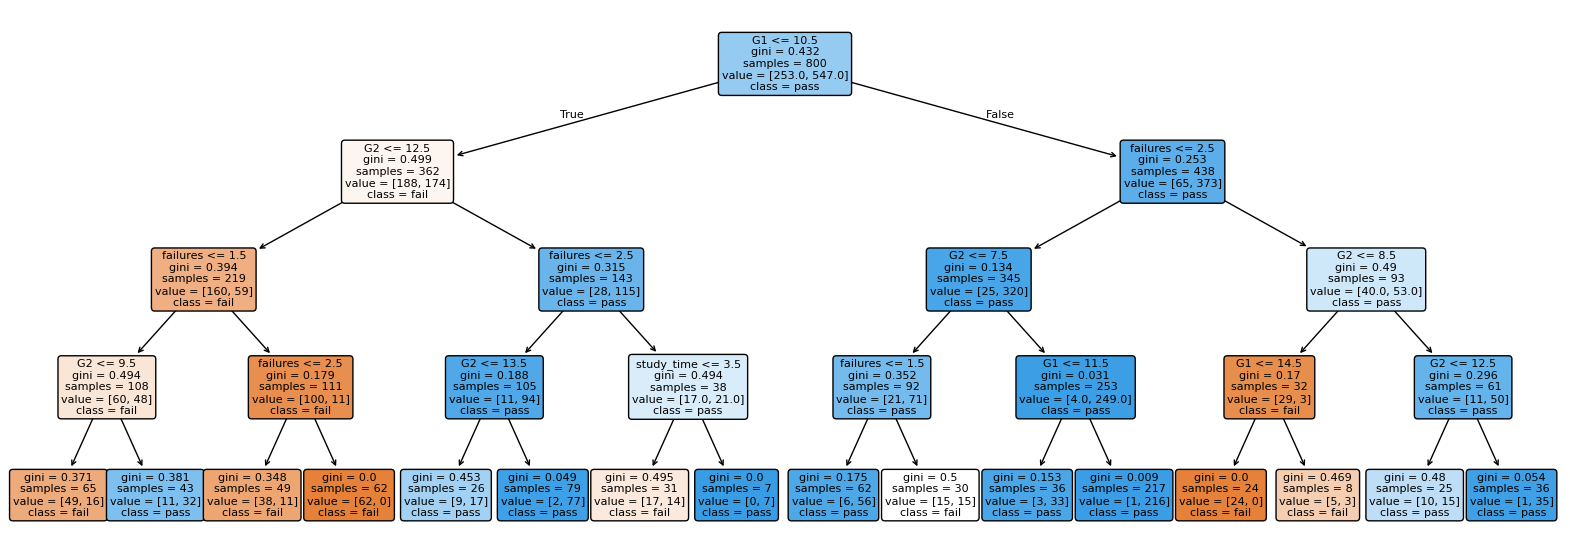

In [98]:
plt.figure(figsize=(20, 7))
plot_tree(dt, feature_names=x_features, class_names=['fail', 'pass'], fontsize=8, rounded=True, filled=True)
plt.show()

In [99]:
# --- Test depths in a loop ---
depths = range(1, 21)  # test depth 1 to 20
train_accs = []
test_accs = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    train_acc = dt.score(X_train, y_train)
    test_acc  = dt.score(X_test, y_test)
    
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    print(f"Depth {depth:2d} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")





Depth  1 | Train Acc: 0.7013 | Test Acc: 0.6550
Depth  2 | Train Acc: 0.8100 | Test Acc: 0.7600
Depth  3 | Train Acc: 0.8425 | Test Acc: 0.7850
Depth  4 | Train Acc: 0.8725 | Test Acc: 0.8400
Depth  5 | Train Acc: 0.9075 | Test Acc: 0.8550
Depth  6 | Train Acc: 0.9300 | Test Acc: 0.8650
Depth  7 | Train Acc: 0.9513 | Test Acc: 0.8500
Depth  8 | Train Acc: 0.9725 | Test Acc: 0.8350
Depth  9 | Train Acc: 0.9825 | Test Acc: 0.8550
Depth 10 | Train Acc: 0.9875 | Test Acc: 0.8550
Depth 11 | Train Acc: 0.9888 | Test Acc: 0.8400
Depth 12 | Train Acc: 0.9900 | Test Acc: 0.8400
Depth 13 | Train Acc: 0.9900 | Test Acc: 0.8400
Depth 14 | Train Acc: 0.9900 | Test Acc: 0.8400
Depth 15 | Train Acc: 0.9900 | Test Acc: 0.8400
Depth 16 | Train Acc: 0.9900 | Test Acc: 0.8400
Depth 17 | Train Acc: 0.9900 | Test Acc: 0.8400
Depth 18 | Train Acc: 0.9900 | Test Acc: 0.8400
Depth 19 | Train Acc: 0.9900 | Test Acc: 0.8400
Depth 20 | Train Acc: 0.9900 | Test Acc: 0.8400


In [100]:
# --- Find best depth ---
best_depth = depths[np.argmax(test_accs)]
best_acc   = max(test_accs)
print(f"\n✅ Best depth: {best_depth} with Test Accuracy: {best_acc:.4f}")


✅ Best depth: 6 with Test Accuracy: 0.8650


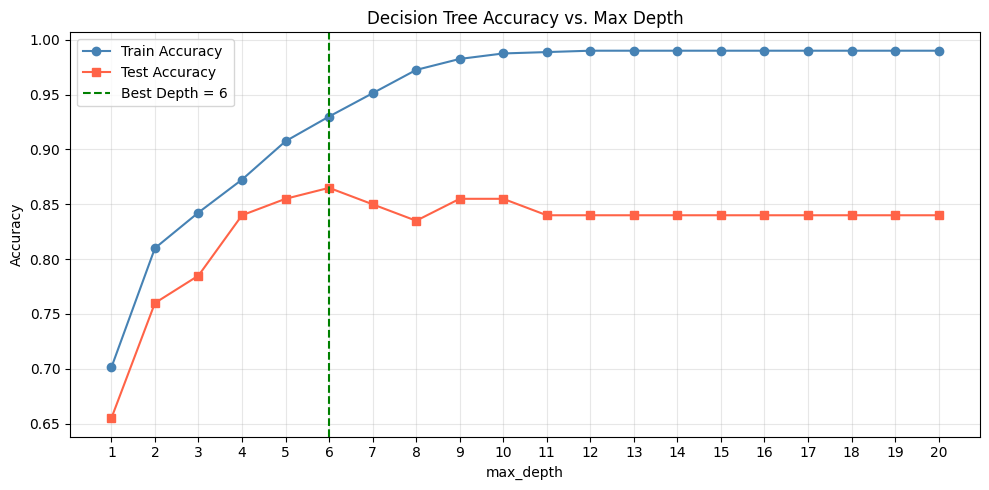

In [101]:
# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(depths, train_accs, marker='o', label='Train Accuracy', color='steelblue')
plt.plot(depths, test_accs,  marker='s', label='Test Accuracy',  color='tomato')
plt.axvline(x=best_depth, color='green', linestyle='--', label=f'Best Depth = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs. Max Depth')
plt.legend()
plt.xticks(depths)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Regression tree

In [102]:
results = []

for depth in range(1, 21):
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)

    test_rmse = np.sqrt(mean_squared_error(y_test, dt.predict(X_test)))
    test_r2   = r2_score(y_test, dt.predict(X_test))
    results.append((depth, test_rmse, test_r2))

    print(f"Depth {depth:2d} | RMSE: {test_rmse:.4f} | R²: {test_r2:.4f}")

# --- Find best depth ---
best = min(results, key=lambda x: x[1])  # lowest RMSE
print(f"\n✅ Best depth: {best[0]}  →  RMSE: {best[1]:.4f} | R²: {best[2]:.4f}")

Depth  1 | RMSE: 0.4583 | R²: 0.0828
Depth  2 | RMSE: 0.4217 | R²: 0.2232
Depth  3 | RMSE: 0.3730 | R²: 0.3922
Depth  4 | RMSE: 0.3559 | R²: 0.4469
Depth  5 | RMSE: 0.3342 | R²: 0.5124
Depth  6 | RMSE: 0.3352 | R²: 0.5093
Depth  7 | RMSE: 0.3419 | R²: 0.4895
Depth  8 | RMSE: 0.3730 | R²: 0.3922
Depth  9 | RMSE: 0.3665 | R²: 0.4134
Depth 10 | RMSE: 0.3725 | R²: 0.3940
Depth 11 | RMSE: 0.3905 | R²: 0.3340
Depth 12 | RMSE: 0.3905 | R²: 0.3340
Depth 13 | RMSE: 0.3905 | R²: 0.3340
Depth 14 | RMSE: 0.3905 | R²: 0.3340
Depth 15 | RMSE: 0.3905 | R²: 0.3340
Depth 16 | RMSE: 0.3905 | R²: 0.3340
Depth 17 | RMSE: 0.3905 | R²: 0.3340
Depth 18 | RMSE: 0.3905 | R²: 0.3340
Depth 19 | RMSE: 0.3905 | R²: 0.3340
Depth 20 | RMSE: 0.3905 | R²: 0.3340

✅ Best depth: 5  →  RMSE: 0.3342 | R²: 0.5124


In [103]:
X = df[x_features].values
y = df['G3'].values
X,y

(array([[ 0,  2,  2,  5,  7],
        [ 0,  3,  3,  5, 12],
        [ 0,  1,  1, 17, 14],
        ...,
        [ 0,  1,  0,  9, 14],
        [ 0,  3,  1, 15,  6],
        [ 0,  1,  3, 14, 10]], shape=(1000, 5)),
 array([ 3.1,  7.2, 16.4, 12.4,  9.8,  6.5,  7.9, 11.8,  9.7, 17.1, 13.7,
         5.5, 11.2, 15.7, 11.7, 11.6, 15.6, 14.8,  8. , 10.3, 13.1,  9.3,
         5.1, 11.8, 15.3, 10.1,  9.9,  8.9, 10.3,  5.3, 15.2, 17.3,  6.5,
        12.4,  9. , 17.5, 14.8,  8.9, 12.9,  8.9, 11.9, 10.1,  9.9,  7.9,
         8.5,  9.5,  8.7, 11. , 12.6, 10.7, 12.9,  7.5,  8.7,  9.8,  4.1,
         5.5, 13.6, 14.5, 14. ,  8.4, 14.4,  6.4, 15.7,  6.8,  7.7,  9.4,
        12.1, 17. , 11. ,  9.6, 15.7,  6.7,  9.5,  9.3,  7.9, 13.7,  6.8,
        11.3, 14.4, 14.2, 11.7, 11.8, 10.3, 16.8, 17.6, 14.3,  9.6, 16.3,
        12.9, 15.5, 13.3, 11.7, 13.1, 11.8, 14.9,  6.8, 12.3, 10.4, 17.3,
        13.6, 15. , 16.5, 17. , 13.3, 12.5, 16. ,  7.6,  8.8,  5.5, 11.3,
         9. , 13.6, 11.1, 13.3, 14.7, 13.7, 13.7

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((800, 5), (800,), (200, 5), (200,))

In [105]:
dt_regressor = DecisionTreeRegressor(max_depth=7, random_state=42)
dt_regressor.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [106]:
y_pred_train = dt_regressor.predict(X_train)
y_pred = dt_regressor.predict(X_test)
mean_squared_error(y_pred, y_test)

2.888587349949248

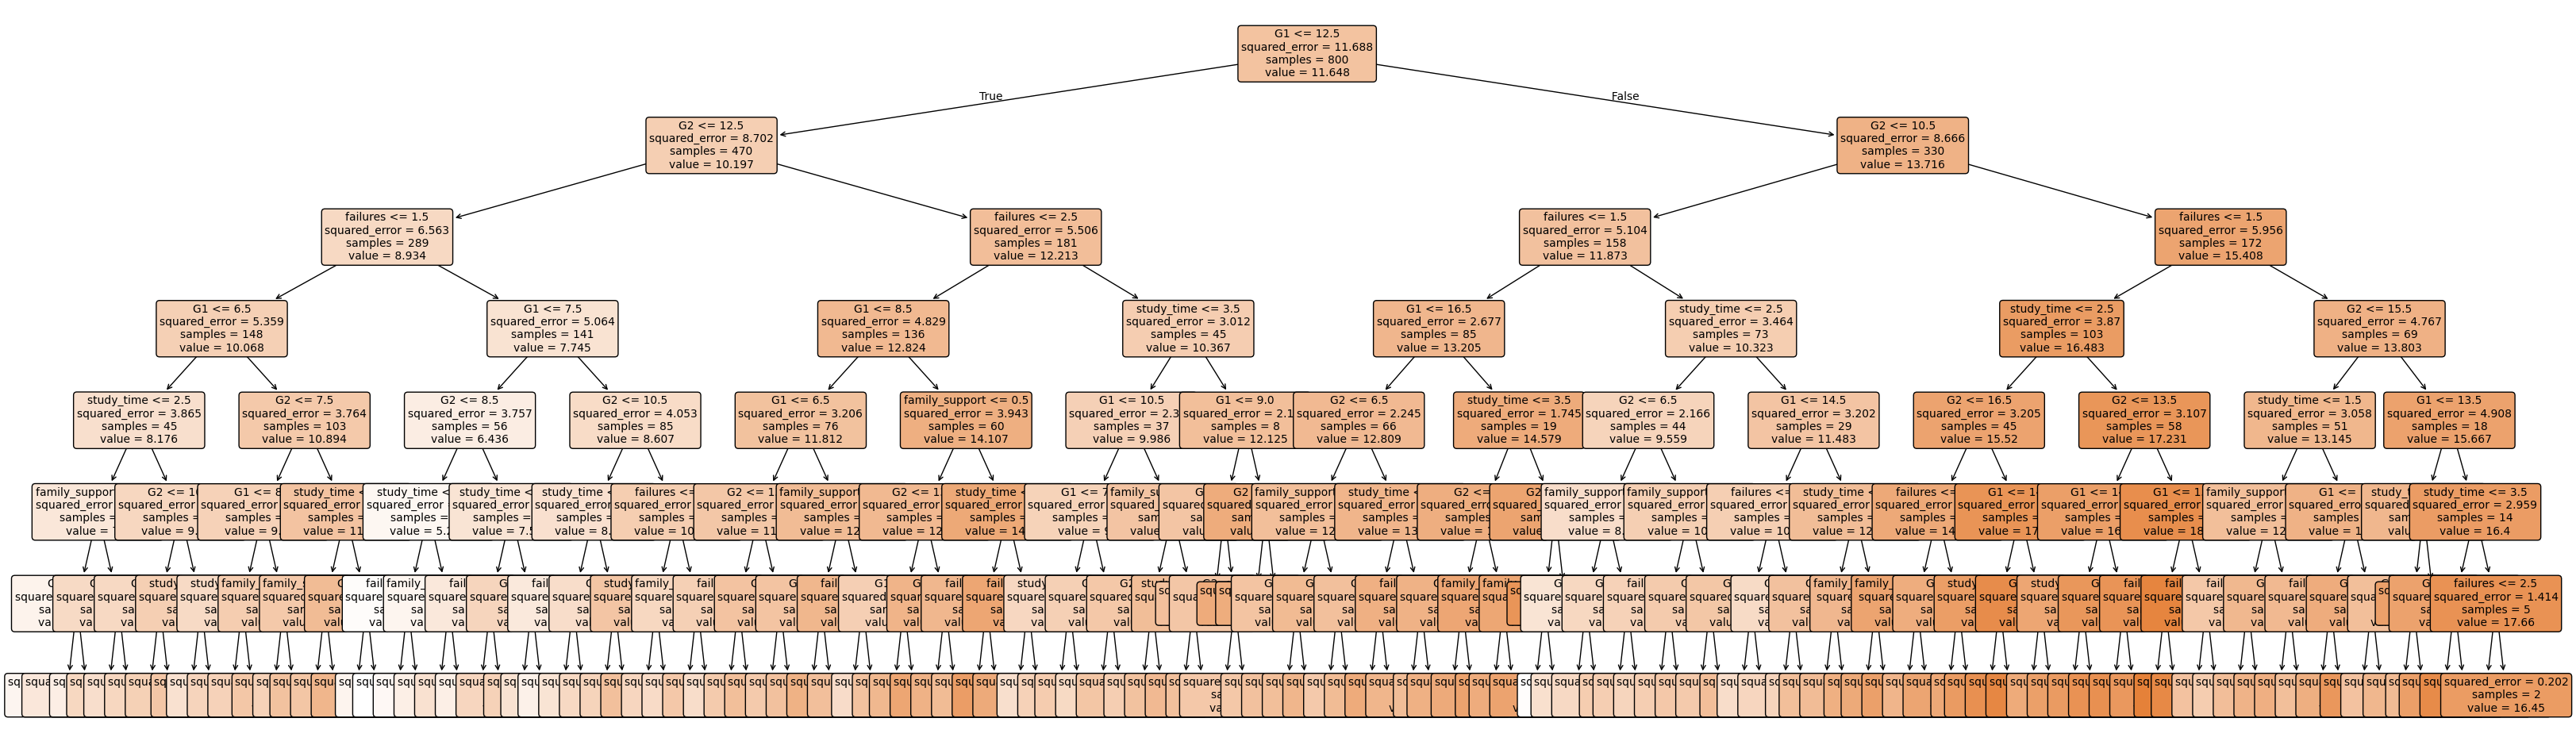

In [107]:
plt.figure(figsize=(40, 12))
plot_tree(dt_regressor, feature_names=x_features, fontsize=10, rounded=True, filled=True)
plt.show()

In [108]:
# --- Test depths in a loop ---
depths = range(1, 21)  # test depth 1 to 20
train_mses = []
test_mses = []
test_mse = []
train_mse = []


for depth in depths:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    y_pred_train = dt.predict(X_train)
    y_pred = dt.predict(X_test)
    train_mse = mean_squared_error(y_pred_train, y_train)
    test_mse  = mean_squared_error(y_pred, y_test)
    
    train_mses.append(train_mse)
    test_mses.append(test_mse)
    
    print(f"Depth {depth:2d} | Train MSE: {train_mse:.4f} | Test MSE: {test_mse:.4f}")

# --- Find best depth ---
best_depth = depths[np.argmin(test_mses)]
best_mse   = min(test_mses)
print(f"\n✅ Best depth: {best_depth} with Test MSE: {best_mse:.4f}")

Depth  1 | Train MSE: 8.6871 | Test MSE: 9.0282
Depth  2 | Train MSE: 5.9051 | Test MSE: 5.9117
Depth  3 | Train MSE: 4.3841 | Test MSE: 4.1679
Depth  4 | Train MSE: 3.3004 | Test MSE: 3.5647
Depth  5 | Train MSE: 2.4330 | Test MSE: 3.4064
Depth  6 | Train MSE: 1.7527 | Test MSE: 3.0738
Depth  7 | Train MSE: 1.1971 | Test MSE: 2.8886
Depth  8 | Train MSE: 0.7717 | Test MSE: 2.9849
Depth  9 | Train MSE: 0.4133 | Test MSE: 2.9450
Depth 10 | Train MSE: 0.2237 | Test MSE: 3.0474
Depth 11 | Train MSE: 0.1199 | Test MSE: 2.9178
Depth 12 | Train MSE: 0.0890 | Test MSE: 3.0644
Depth 13 | Train MSE: 0.0859 | Test MSE: 2.9308
Depth 14 | Train MSE: 0.0856 | Test MSE: 2.9094
Depth 15 | Train MSE: 0.0855 | Test MSE: 3.0214
Depth 16 | Train MSE: 0.0855 | Test MSE: 3.0214
Depth 17 | Train MSE: 0.0855 | Test MSE: 3.0214
Depth 18 | Train MSE: 0.0855 | Test MSE: 3.0214
Depth 19 | Train MSE: 0.0855 | Test MSE: 3.0214
Depth 20 | Train MSE: 0.0855 | Test MSE: 3.0214

✅ Best depth: 7 with Test MSE: 2.8886


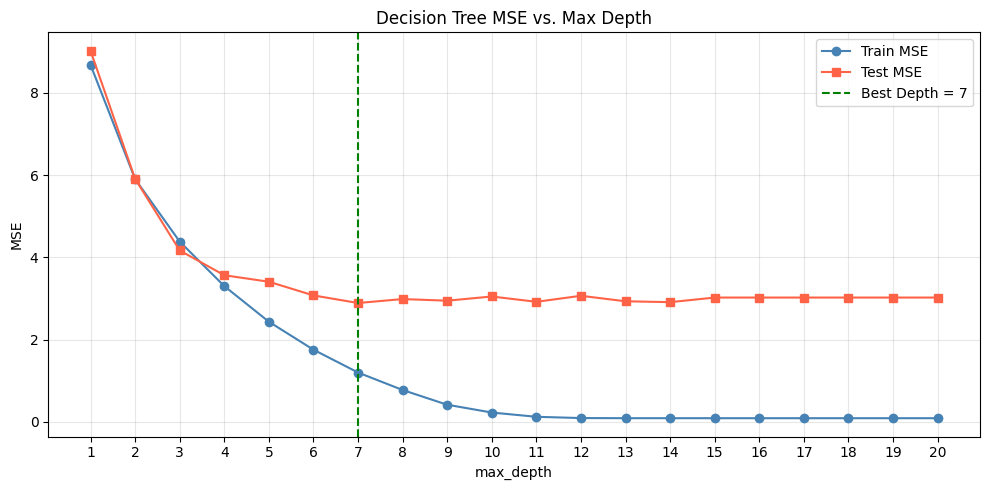

In [109]:
# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(depths, train_mses, marker='o', label='Train MSE', color='steelblue')
plt.plot(depths, test_mses,  marker='s', label='Test MSE',  color='tomato')
plt.axvline(x=best_depth, color='green', linestyle='--', label=f'Best Depth = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('MSE')
plt.title('Decision Tree MSE vs. Max Depth')
plt.legend()
plt.xticks(depths)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## linear regression

In [110]:
from sklearn.linear_model import LinearRegression, LogisticRegression

In [111]:
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train, y_train)
linear_mse = mean_squared_error(linear_reg_model.predict(X_test), y_test)
print(f"Linear Regression Test MSE: {linear_mse:.4f}")

Linear Regression Test MSE: 1.1986


In [112]:
x_features = ['family_support', 'study_time', 'failures', 'G1', 'G2']
X = df[x_features].values
y = df['pass_fail'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [113]:
logistic_reg_model = LogisticRegression()
logistic_reg_model.fit(X_train, y_train)
logistic_acc = logistic_reg_model.score(X_test, y_test)
print(f"Logistic Regression Test Accuracy: {logistic_acc:.4f}")

Logistic Regression Test Accuracy: 0.8950


## Randon forest

In [114]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

## Random forest classifier

In [115]:
x_features = ['family_support', 'study_time', 'failures', 'G1', 'G2']
X = df[x_features].values
y = df['pass_fail'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [131]:
random_forest_clf = RandomForestClassifier(n_estimators=12, max_depth=10, random_state=42)
random_forest_clf.fit(X_train, y_train)
random_forest_clf_acc = accuracy_score(random_forest_clf.predict(X_test), y_test)
random_forest_clf_acc

0.91

# Find best depth

In [124]:
# --- Test depths in a loop ---
depths = range(1, 21)  # test depth 1 to 20
train_accs = []
test_accs = []

for depth in depths:
    dt = RandomForestClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    train_acc = dt.score(X_train, y_train)
    test_acc  = dt.score(X_test, y_test)
    
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    print(f"Depth {depth:2d} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

    # --- Find best depth ---
best_depth = depths[np.argmax(test_accs)]
best_acc   = max(test_accs)
print(f"\n✅ Best depth: {best_depth} with Test Accuracy: {best_acc:.4f}")


Depth  1 | Train Acc: 0.7188 | Test Acc: 0.6650
Depth  2 | Train Acc: 0.8387 | Test Acc: 0.7950
Depth  3 | Train Acc: 0.8875 | Test Acc: 0.8300
Depth  4 | Train Acc: 0.9100 | Test Acc: 0.8400
Depth  5 | Train Acc: 0.9275 | Test Acc: 0.8600
Depth  6 | Train Acc: 0.9537 | Test Acc: 0.8700
Depth  7 | Train Acc: 0.9650 | Test Acc: 0.8800
Depth  8 | Train Acc: 0.9762 | Test Acc: 0.8850
Depth  9 | Train Acc: 0.9838 | Test Acc: 0.8850
Depth 10 | Train Acc: 0.9888 | Test Acc: 0.8900
Depth 11 | Train Acc: 0.9900 | Test Acc: 0.8900
Depth 12 | Train Acc: 0.9900 | Test Acc: 0.8800
Depth 13 | Train Acc: 0.9900 | Test Acc: 0.8850
Depth 14 | Train Acc: 0.9900 | Test Acc: 0.8850
Depth 15 | Train Acc: 0.9900 | Test Acc: 0.8850
Depth 16 | Train Acc: 0.9900 | Test Acc: 0.8850
Depth 17 | Train Acc: 0.9900 | Test Acc: 0.8850
Depth 18 | Train Acc: 0.9900 | Test Acc: 0.8850
Depth 19 | Train Acc: 0.9900 | Test Acc: 0.8850
Depth 20 | Train Acc: 0.9900 | Test Acc: 0.8850

✅ Best depth: 10 with Test Accuracy: 0.

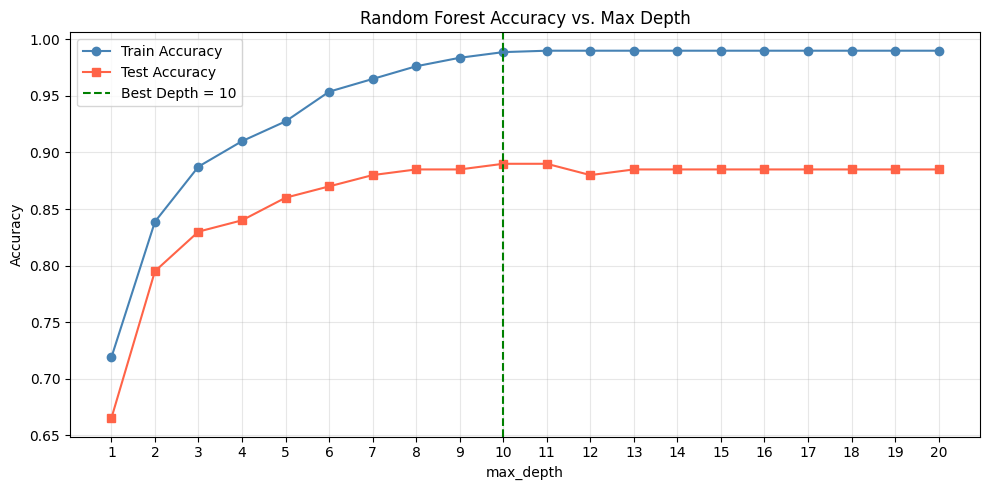

In [128]:
# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(depths, train_accs, marker='o', label='Train Accuracy', color='steelblue')
plt.plot(depths, test_accs,  marker='s', label='Test Accuracy',  color='tomato')
plt.axvline(x=best_depth, color='green', linestyle='--', label=f'Best Depth = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy vs. Max Depth')
plt.legend()
plt.xticks(depths)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find best n_estimator

In [ ]:
# --- Test n_estimators in a loop ---
n_estimators_list = range(10, 201, 1)  # test n_estimators from 10 to 200
train_accs = []
test_accs = []

for n in n_estimators_list:
    for depth in range(1, 21):
        dt = RandomForestClassifier(n_estimators=n, max_depth=depth, random_state=42)
        dt.fit(X_train, y_train)
        train_acc = dt.score(X_train, y_train)
        test_acc  = dt.score(X_test, y_test)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        print(f"n_estimators {n:3d} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Max Depth: {depth}")

    # --- Find best n_estimators ---
best_n_estimators = n_estimators_list[np.argmax(test_accs)]
best_acc   = max(test_accs)
print(f"\n✅ Best n_estimators: {best_n_estimators} with Test Accuracy: {best_acc:.4f} with Max Depth: {best_depth:.4f}")

n_estimators  10 | Train Acc: 0.6975 | Test Acc: 0.6550
n_estimators  10 | Train Acc: 0.8300 | Test Acc: 0.7800
n_estimators  10 | Train Acc: 0.8800 | Test Acc: 0.8350
n_estimators  10 | Train Acc: 0.9175 | Test Acc: 0.8550
n_estimators  10 | Train Acc: 0.9213 | Test Acc: 0.8650
n_estimators  10 | Train Acc: 0.9437 | Test Acc: 0.8850
n_estimators  10 | Train Acc: 0.9575 | Test Acc: 0.8650
n_estimators  10 | Train Acc: 0.9637 | Test Acc: 0.8800
n_estimators  10 | Train Acc: 0.9750 | Test Acc: 0.8700
n_estimators  10 | Train Acc: 0.9775 | Test Acc: 0.8950
n_estimators  10 | Train Acc: 0.9800 | Test Acc: 0.8900
n_estimators  10 | Train Acc: 0.9825 | Test Acc: 0.8850
n_estimators  10 | Train Acc: 0.9825 | Test Acc: 0.8900
n_estimators  10 | Train Acc: 0.9825 | Test Acc: 0.8900
n_estimators  10 | Train Acc: 0.9825 | Test Acc: 0.8900
n_estimators  10 | Train Acc: 0.9825 | Test Acc: 0.8900
n_estimators  10 | Train Acc: 0.9825 | Test Acc: 0.8900
n_estimators  10 | Train Acc: 0.9825 | Test Acc:

IndexError: range object index out of range

## Random forest regressor

In [155]:
X = df[x_features].values
y = df['G3'].values
print(X,y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

[[ 0  2  2  5  7]
 [ 0  3  3  5 12]
 [ 0  1  1 17 14]
 ...
 [ 0  1  0  9 14]
 [ 0  3  1 15  6]
 [ 0  1  3 14 10]] [ 3.1  7.2 16.4 12.4  9.8  6.5  7.9 11.8  9.7 17.1 13.7  5.5 11.2 15.7
 11.7 11.6 15.6 14.8  8.  10.3 13.1  9.3  5.1 11.8 15.3 10.1  9.9  8.9
 10.3  5.3 15.2 17.3  6.5 12.4  9.  17.5 14.8  8.9 12.9  8.9 11.9 10.1
  9.9  7.9  8.5  9.5  8.7 11.  12.6 10.7 12.9  7.5  8.7  9.8  4.1  5.5
 13.6 14.5 14.   8.4 14.4  6.4 15.7  6.8  7.7  9.4 12.1 17.  11.   9.6
 15.7  6.7  9.5  9.3  7.9 13.7  6.8 11.3 14.4 14.2 11.7 11.8 10.3 16.8
 17.6 14.3  9.6 16.3 12.9 15.5 13.3 11.7 13.1 11.8 14.9  6.8 12.3 10.4
 17.3 13.6 15.  16.5 17.  13.3 12.5 16.   7.6  8.8  5.5 11.3  9.  13.6
 11.1 13.3 14.7 13.7 13.7  9.3 12.   7.9 10.  16.2 10.2 15.7  6.6 14.6
 12.1 14.9 10.6  7.  16.1 11.  12.9 19.8 14.8 14.8  8.3  8.1 17.2 10.6
  6.2 10.1 18.7 14.6 19.6  9.8 11.4 14.6 12.9 12.5 14.6 10.6 14.3 14.4
 12.   6.1  5.8 13.3 10.9 15.  13.3 13.1 14.5  9.3 16.5  9.1  6.8 10.4
 12.9  9.2  9.6  9.2  8.1 12.4 14.

((800, 5), (800,), (200, 5), (200,))

In [157]:
random_forest_rgs = RandomForestRegressor(n_estimators=99, max_depth=12, random_state=42)
random_forest_rgs.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",99
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [158]:
y_pred = random_forest_rgs.predict(X_test)
mean_squared_error(y_pred, y_test)

1.505120940648865

## Best depth

In [139]:
# --- Test depths in a loop ---
depths = range(1, 21)  # test depth 1 to 20
train_mses = []
test_mses = []
test_mse = []
train_mse = []


for depth in depths:
    dt = RandomForestRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    y_pred_train = dt.predict(X_train)
    y_pred = dt.predict(X_test)
    train_mse = mean_squared_error(y_pred_train, y_train)
    test_mse  = mean_squared_error(y_pred, y_test)
    
    train_mses.append(train_mse)
    test_mses.append(test_mse)
    
    print(f"Depth {depth:2d} | Train MSE: {train_mse:.4f} | Test MSE: {test_mse:.4f}")

# --- Find best depth ---
best_depth = depths[np.argmin(test_mses)]
best_mse   = min(test_mses)
print(f"\n✅ Best depth: {best_depth} with Test MSE: {best_mse:.4f}")

Depth  1 | Train MSE: 7.2716 | Test MSE: 7.0233
Depth  2 | Train MSE: 5.0323 | Test MSE: 4.8039
Depth  3 | Train MSE: 3.2644 | Test MSE: 3.0814
Depth  4 | Train MSE: 2.2473 | Test MSE: 2.4134
Depth  5 | Train MSE: 1.5614 | Test MSE: 1.9868
Depth  6 | Train MSE: 1.0829 | Test MSE: 1.6974
Depth  7 | Train MSE: 0.7513 | Test MSE: 1.5668
Depth  8 | Train MSE: 0.5245 | Test MSE: 1.5218
Depth  9 | Train MSE: 0.3871 | Test MSE: 1.5118
Depth 10 | Train MSE: 0.3178 | Test MSE: 1.5136
Depth 11 | Train MSE: 0.2903 | Test MSE: 1.5086
Depth 12 | Train MSE: 0.2807 | Test MSE: 1.5028
Depth 13 | Train MSE: 0.2780 | Test MSE: 1.5114
Depth 14 | Train MSE: 0.2782 | Test MSE: 1.5137
Depth 15 | Train MSE: 0.2782 | Test MSE: 1.5163
Depth 16 | Train MSE: 0.2784 | Test MSE: 1.5135
Depth 17 | Train MSE: 0.2784 | Test MSE: 1.5137
Depth 18 | Train MSE: 0.2784 | Test MSE: 1.5137
Depth 19 | Train MSE: 0.2784 | Test MSE: 1.5137
Depth 20 | Train MSE: 0.2784 | Test MSE: 1.5137

✅ Best depth: 12 with Test MSE: 1.5028


## Best n_estimator

In [ ]:
min_mse = 100
e = 0
d = 0
for n_estimators in range(1, 101 , 1):
    for depth in range(1, 21):
       random_forest_rgs = RandomForestRegressor(n_estimators=n_estimators, max_depth=depth, random_state=42)
       random_forest_rgs.fit(X_train, y_train)
       random_forest_rgs_mse = mean_squared_error(random_forest_rgs.predict(X_test), y_test)
       if random_forest_rgs_mse < min_mse:
           min_mse = random_forest_rgs_mse
           e = n_estimators
           d = depth

In [156]:
e ,d

(99, 12)

In [151]:
np.argmax(test_accs)

np.int64(2751)